**Qualitative Data**

Nominal Data: Catagorical Data where observations are labeled into distant categories. Example: Gender

Ordinal Data: Catagorical Data with a meaningful order of ranking between the categories. Example: Education Level (Elementry, Middle School, High School)

**Quantitative Data**

interval data: Data where the difference between values is meaningfull but the ratio of the values is not meaningfull (no zero, points, and  negitave values). Example: Calender (month, day, year)

ratio data: Data where the difference between values and the ratio of the values is meaningfull (no negative values). Examples: Height, Weight, Age, Time etc.

- Logistic regression is a Machine Learning method used for classification tasks.


- It is a predictive analytic technique based on the probability idea.


- The dependent variable in logistic regression is binary (coded as 1 or 0).


- The goal is to discover a link between characteristics and the likelihood of a specific outcome.

The mathematically sigmoid function can be,

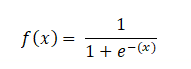

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

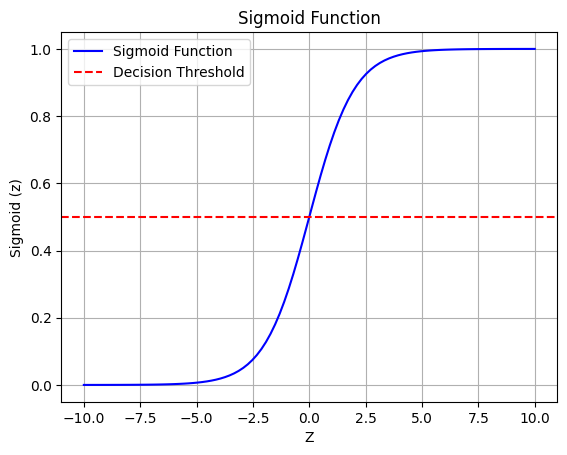

In [85]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)

sigmoid_values = sigmoid(z)

plt.plot(z, sigmoid_values, "b-", label = "Sigmoid Function")
plt.axhline(y = 0.5, color = "red", linestyle = "--", label = "Decision Threshold")

plt.xlabel("Z")
plt.ylabel("Sigmoid (z)")
plt.title("Sigmoid Function")

plt.grid()
plt.legend()

plt.show()

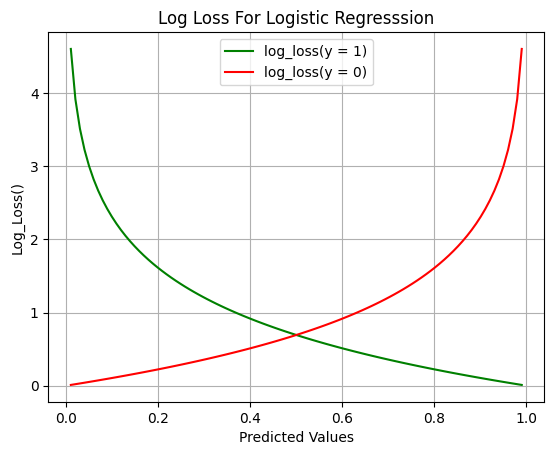

In [86]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def log_loss(y_true, y_pred):
  return -y_true * np.log(y_pred) - (1 - y_true) * np.log(1 - y_pred)

y_pred_values = np.linspace(0.01, 0.99, 100)
log_loss_positive = log_loss(1, y_pred_values)
log_loss_negative = log_loss(0, y_pred_values)

plt.plot(y_pred_values, log_loss_positive, color = "green", label = "log_loss(y = 1)")
plt.plot(y_pred_values, log_loss_negative, color = "red", label = "log_loss(y = 0)")

plt.xlabel("Predicted Values")
plt.ylabel("Log_Loss()")
plt.title("Log Loss For Logistic Regresssion")

plt.legend()
plt.grid()

plt.show()

In [87]:
df = pd.read_csv("/content/hearing_test1.csv")

df

,AGE,Average of physical_score,Average of test_result
0,18,48,1
1,21,46,1
2,22,46,1
3,23,44,1
4,24,47,1
...,...,...,...
64,84,16,0
65,85,25,0
66,86,22,0
67,87,12,0


Dataframe is about a hearing test conducted on participants. Average of test_result determines if they passed or not, with (0) being no pass and (1) being passed If the Average of physical_score is greater than or equal to 32, it is considered passing, otherwise it is considered failing

<ipython-input-88-ab9605b6f8ac>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = "Average of test_result", palette = "mako")


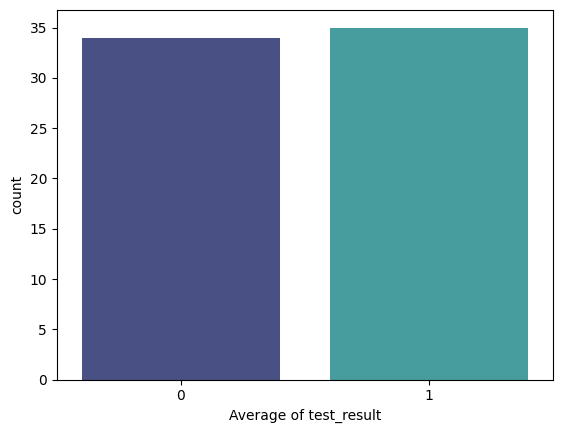

In [88]:
sns.countplot(data = df, x = "Average of test_result", palette = "mako")

plt.show()

In [89]:
df["Average of test_result"].value_counts()

Average of test_result
1    35
0    34
Name: count, dtype: int64

<ipython-input-90-8bf377cc4497>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Average of test_result", y = "AGE", palette = "magma")


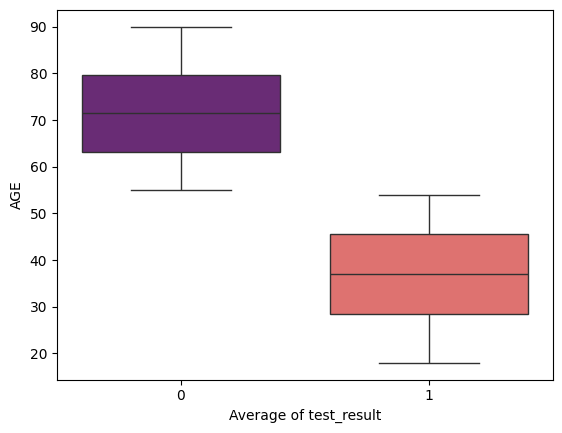

In [90]:
sns.boxplot(data = df, x = "Average of test_result", y = "AGE", palette = "magma")

plt.show()

<ipython-input-91-d5a955a1b595>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Average of test_result", y = "Average of physical_score", palette = "magma")


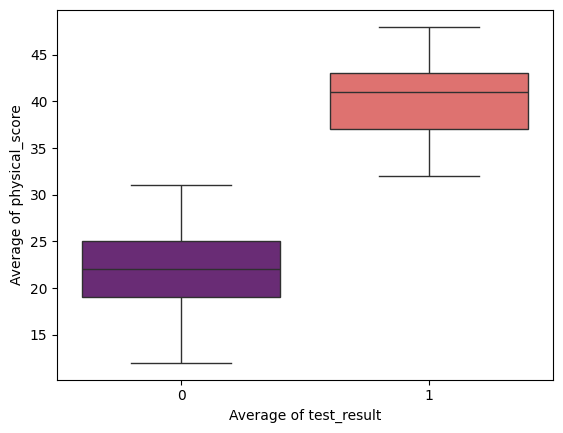

In [91]:
sns.boxplot(data = df, x = "Average of test_result", y = "Average of physical_score", palette = "magma")

plt.show()

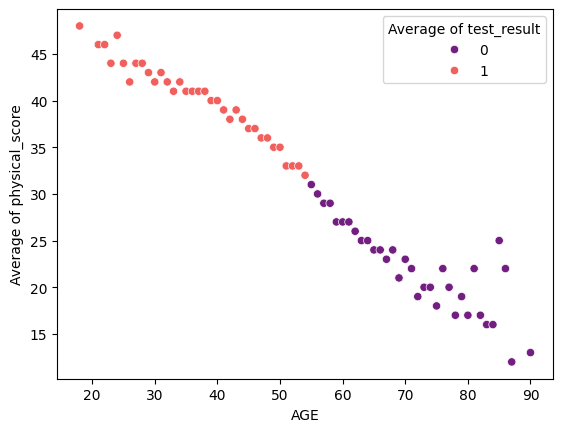

In [92]:
sns.scatterplot(data = df, x = "AGE", y = "Average of physical_score", hue = "Average of test_result", palette = "magma")

plt.show()

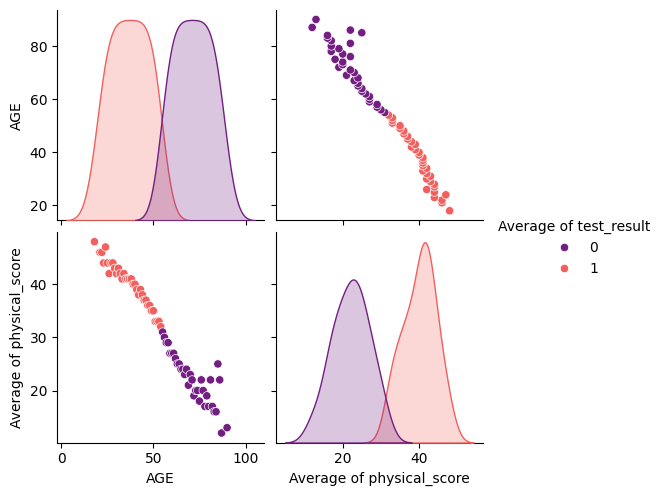

In [93]:
sns.pairplot(data = df, hue = "Average of test_result", palette = "magma")

plt.show()

<Axes: >

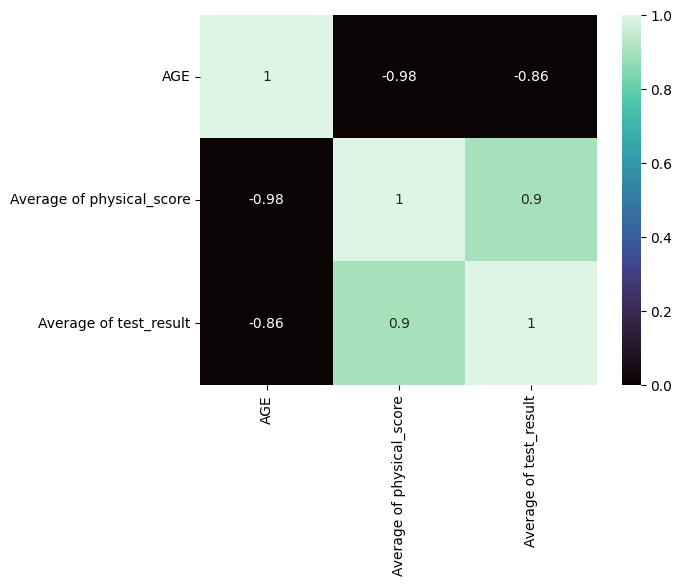

In [94]:
sns.heatmap(df.corr(), annot = True, cmap = "mako", vmin = 0)

<ipython-input-95-e1aa42bd29a3>:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = df, x = "Average of physical_score", y = "Average of test_result", palette = "magma")


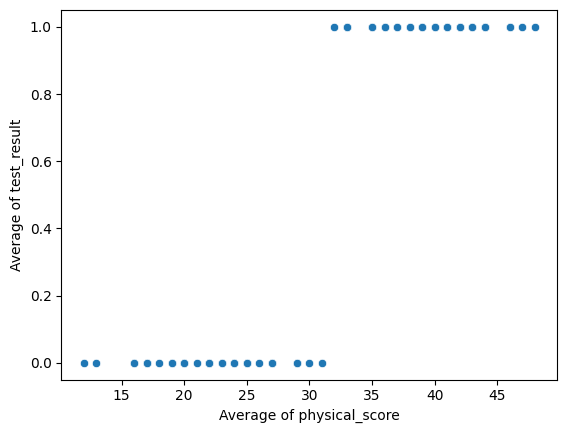

In [95]:
sns.scatterplot(data = df, x = "Average of physical_score", y = "Average of test_result", palette = "magma")

plt.show()

<ipython-input-96-4ce60cb8b186>:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = df, x = "AGE", y = "Average of test_result", palette = "magma")


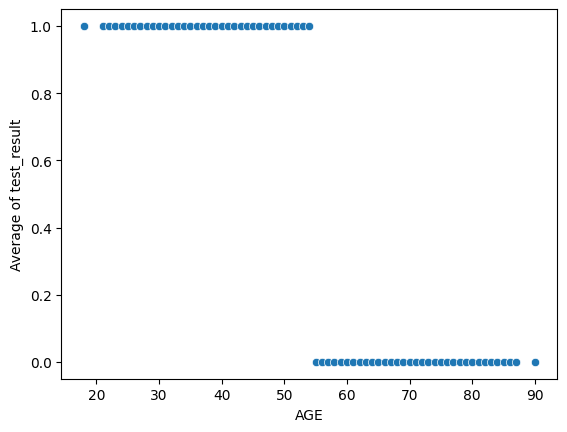

In [96]:
sns.scatterplot(data = df, x = "AGE", y = "Average of test_result", palette = "magma")

plt.show()

In [97]:
x = df.drop("Average of test_result", axis = 1)
y = df["Average of test_result"]

In [98]:
x

,AGE,Average of physical_score
0,18,48
1,21,46
2,22,46
3,23,44
4,24,47
...,...,...
64,84,16
65,85,25
66,86,22
67,87,12


In [99]:
y

0     1
1     1
2     1
3     1
4     1
     ..
64    0
65    0
66    0
67    0
68    0
Name: Average of test_result, Length: 69, dtype: int64

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 0)

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
scaler = StandardScaler()

In [104]:
scale_x_train = scaler.fit_transform(x_train)
scale_x_test = scaler.fit_transform(x_test)

In [105]:
scale_x_train

array([[-1.44720378,  1.3557673 ],
       [ 1.12194319, -1.26342402],
       [-1.00254373,  1.05355292],
       [-1.39779711,  1.15429104],
       [ 1.07253652, -1.26342402],
       [ 1.91244995, -1.96859091],
       [-1.0519504 ,  0.95281479],
       [ 0.43024977, -0.55825712],
       [ 0.82550315, -0.86047151],
       [ 0.67728314, -0.86047151],
       [ 1.22075653, -1.06194776],
       [ 0.03499639,  0.04617164],
       [-0.85432371,  0.95281479],
       [ 1.17134986, -1.46490027],
       [-0.60729035,  0.75133853],
       [-0.11322362,  0.2476479 ],
       [ 0.97372317, -1.06194776],
       [ 0.18321641, -0.15530461],
       [-0.65669702,  0.85207666],
       [-1.64483047,  1.55724355],
       [-0.80491704,  0.85207666],
       [-1.29898377,  1.15429104],
       [-0.75551037,  0.85207666],
       [-0.55788368,  0.75133853],
       [ 1.66541659, -0.75973338],
       [-1.15076375,  1.15429104],
       [-0.90373039,  0.85207666],
       [-0.31085031,  0.44912415],
       [ 0.28202976,

In [106]:
from sklearn.linear_model import LogisticRegression

In [107]:
log_model = LogisticRegression()
log_model.fit(scale_x_train, y_train)

LogisticRegression()

In [108]:
print(log_model.coef_)
print(log_model.intercept_)

[[-1.60223084  1.92741153]]
[0.07566769]


In [109]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [110]:
y_pred = log_model.predict(scale_x_test)

In [111]:
accuracy_score(y_pred, y_test)

1.0

[Confusion Matrix](https://medium.com/analytics-vidhya/what-is-a-confusion-matrix-d1c0f8feda5)

In [112]:
print(confusion_matrix(y_test, y_pred))

[[11  0]
 [ 0 10]]


In [113]:
data = pd.read_csv("/content/spam.csv", encoding = 'latin-1')

data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [114]:
data = data[["v1", "v2"]]

data

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [115]:
newColoumnNames = {"v1": "label", "v2": "message"}
data.rename(columns = newColoumnNames, inplace = True)

<ipython-input-115-7920d58353a6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.rename(columns = newColoumnNames, inplace = True)


In [116]:
data["label"] = data["label"].map({"ham": 0, "spam": 1})

<ipython-input-116-6b93ec56d733>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["label"] = data["label"].map({"ham": 0, "spam": 1})


In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [118]:
x = data["message"]
y = data["label"]

In [119]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 0)

In [120]:
print(x.shape)
print(x_train.shape)
print(x_test.shape)

(5572,)
(3900,)
(1672,)


In [121]:
from sklearn.feature_extraction.text import CountVectorizer

Frequency distribution Our objective here is to convert this set of text to a frequency distribution matrix
Note
The CountVectorizer method automatically converts all tokenized words to their lower case form so that it does not treat words like 'He' and 'he' differently. It does this using the lowercase parameter which is by default set to True.
It also ignores all punctuation so that words followed by a punctuation mark (for example: 'hello!') are not treated differently than the same words not prefixed or suffixed by a punctuation mark (for example: 'hello').

In [122]:
count_vector = CountVectorizer()

In [123]:
training_data = count_vector.fit_transform(x_train).toarray()

In [124]:
training_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [125]:
testing_data = count_vector.transform(x_test).toarray()

In [126]:
testing_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [127]:
clf = LogisticRegression(random_state = 0)

In [128]:
clf.fit(training_data, y_train)

LogisticRegression(random_state=0)

In [129]:
y_pred = clf.predict(testing_data)

In [130]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [131]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score

In [132]:
print("Accuracy Score:", accuracy_score(y_pred, y_test))

Accuracy Score: 0.9778708133971292


In [133]:
print("Precision Score:", precision_score(y_pred, y_test))

Precision Score: 0.8529411764705882


In [134]:
print("Confusion Matrix Score:\n", confusion_matrix(y_pred, y_test))

Confusion Matrix Score:
 [[1432   35]
 [   2  203]]


In [135]:
print("Recall Score:", recall_score(y_pred, y_test))

Recall Score: 0.9902439024390244


**Multi Logistic Regression**

In [136]:
from sklearn.datasets import load_iris

In [137]:
data = load_iris()

In [138]:
x = data.data
y = data.target

In [139]:
df = pd.DataFrame(data.data, columns = data.feature_names)

In [140]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [141]:
df["target"] = data.target

In [142]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [143]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 0)

In [144]:
scaler = StandardScaler()

In [145]:
scale_x_train = scaler.fit_transform(x_train)
scale_x_test = scaler.transform(x_test)

In [146]:
scale_x_train

array([[-1.02366372, -2.37846268, -0.18295039, -0.29318114],
       [ 0.69517462, -0.10190314,  0.93066067,  0.7372463 ],
       [ 0.92435306,  0.58106472,  1.04202177,  1.63887031],
       [ 0.1222285 , -1.92315077,  0.6522579 ,  0.35083601],
       [ 0.92435306, -1.24018291,  1.09770233,  0.7372463 ],
       [-0.33612839, -1.24018291,  0.03977182, -0.16437771],
       [ 2.07024529, -0.10190314,  1.26474398,  1.38126345],
       [ 0.46599617,  0.58106472,  0.48521625,  0.47963944],
       [-0.45071761, -1.46783886, -0.01590873, -0.16437771],
       [ 0.46599617, -0.784871  ,  0.59657735,  0.7372463 ],
       [ 0.46599617, -0.55721505,  0.70793846,  0.35083601],
       [-1.13825295, -1.24018291,  0.37385514,  0.60844287],
       [ 0.46599617, -1.24018291,  0.6522579 ,  0.86604973],
       [ 1.26812073,  0.35340877,  0.48521625,  0.22203258],
       [ 0.69517462, -0.10190314,  0.76361901,  0.99485316],
       [ 0.1222285 ,  0.80872067,  0.37385514,  0.47963944],
       [-1.25284217,  0.

In [147]:
scale_x_test

array([[-0.10694994, -0.55721505,  0.70793846,  1.51006688],
       [ 0.1222285 , -1.92315077,  0.09545238, -0.29318114],
       [-0.45071761,  2.6299683 , -1.35224199, -1.32360858],
       [ 1.6118884 , -0.32955909,  1.37610509,  0.7372463 ],
       [-1.02366372,  0.80872067, -1.29656144, -1.32360858],
       [ 0.46599617,  0.58106472,  1.20906343,  1.63887031],
       [-1.02366372,  1.03637663, -1.40792255, -1.19480515],
       [ 0.92435306,  0.12575281,  0.48521625,  0.35083601],
       [ 1.03894229, -0.55721505,  0.5408968 ,  0.22203258],
       [ 0.23681773, -0.55721505,  0.09545238,  0.09322915],
       [ 0.23681773, -1.01252695,  0.98634122,  0.22203258],
       [ 0.5805854 ,  0.35340877,  0.37385514,  0.35083601],
       [ 0.23681773, -0.55721505,  0.48521625, -0.03557428],
       [ 0.69517462, -0.55721505,  0.42953569,  0.35083601],
       [ 0.23681773, -0.32955909,  0.48521625,  0.22203258],
       [-1.13825295,  1.26403258, -1.35224199, -1.45241201],
       [ 0.1222285 , -0.

In [148]:
lr = LogisticRegression()

lr.fit(scale_x_train, y_train)

LogisticRegression()

In [149]:
y_pred = lr.predict(x_test)

y_pred

array([2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 2, 2,
       2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       1])

In [152]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average = 'macro')
recall = recall_score(y_test, y_pred, average='macro')
confusion = confusion_matrix(y_test, y_pred)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [155]:
print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("confusion:", confusion)

accuracy: 0.24444444444444444
precision: 0.10784313725490197
recall: 0.3333333333333333
confusion: [[ 0 11  5]
 [ 0  0 18]
 [ 0  0 11]]
